# Punto 12 — Revisión de la estacionalidad

Se revisa si representar mejor los ciclos mejora las predicciones. La referencia disponible es el modelo elegido en el punto 5. No hay otro trabajo anterior en las carpetas; por eso, la comparación se realiza con esa referencia.

En viajes se distinguen ciclos semanales y anuales. En temperatura y humedad predomina el ciclo anual. La precipitación se mantiene como referencia: no se impone una diferencia estacional sin respaldo.

Se agrega una alternativa con **dos pares de senos y cosenos anuales**, que dibujan un patrón suave durante el año. Para viajes se incluye además una tendencia y errores SARIMA(1,0,1)(1,0,0)₇. Para temperatura y humedad se usan errores AR(1). Estas alternativas son **regresiones de calendario con errores SARIMA (SARIMAX)**: utilizan datos de fechas, no valores climáticos futuros.

La comparación usa los mismos últimos 90 días de entrenamiento del punto 5. El modelo con menor MAE de validación se recalcula con 2023–2024 y se evalúa en 2025. La prueba no decide el ganador. La referencia ya fue elegida con esa validación, por lo que seguir probando alternativas en la misma ventana puede favorecer un ajuste excesivo a ella.

Esta comparación amplía el conjunto de opciones. No demuestra que el ganador sea la única representación correcta de la estacionalidad.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data/bicicletas_rosario.csv').exists())
if str(ROOT/'scripts') not in sys.path: sys.path.insert(0,str(ROOT/'scripts'))
from modelos_puntos56 import cargar, ajustar, ajustados, pronosticar, metricas, etiqueta
from modelos_resto import *
series=cargar(ROOT)
seleccion=json.loads((ROOT/'puntos/punto5/seleccion.json').read_text())
plt.rcParams.update({'figure.figsize':(11,4),'figure.dpi':120})


**Viajes MBTB:** se elige **SARIMA punto 5** por validación.

**Temperatura:** se elige **Ciclo anual + AR(1)** por validación.

**Humedad:** se elige **Ciclo anual + AR(1)** por validación.

**Precipitación:** se elige **SARIMA punto 5** por validación.

,serie,modelo,MAE_validacion,MAE_testing,RMSE_testing,advertencias,elegido_validacion
0,Viajes MBTB,SARIMA punto 5,424.572,512.524,635.599,,True
1,Viajes MBTB,SARIMA semanal + ciclo anual,1596.679,2429.394,2575.886,,False
2,Temperatura,SARIMA punto 5,3.141,3.959,4.926,,False
3,Temperatura,Ciclo anual + AR(1),2.514,2.653,3.356,,True
4,Humedad,SARIMA punto 5,10.388,11.474,13.611,,False
5,Humedad,Ciclo anual + AR(1),6.771,8.745,11.025,,True
6,Precipitación,SARIMA punto 5,4.549,4.770,10.350,,True


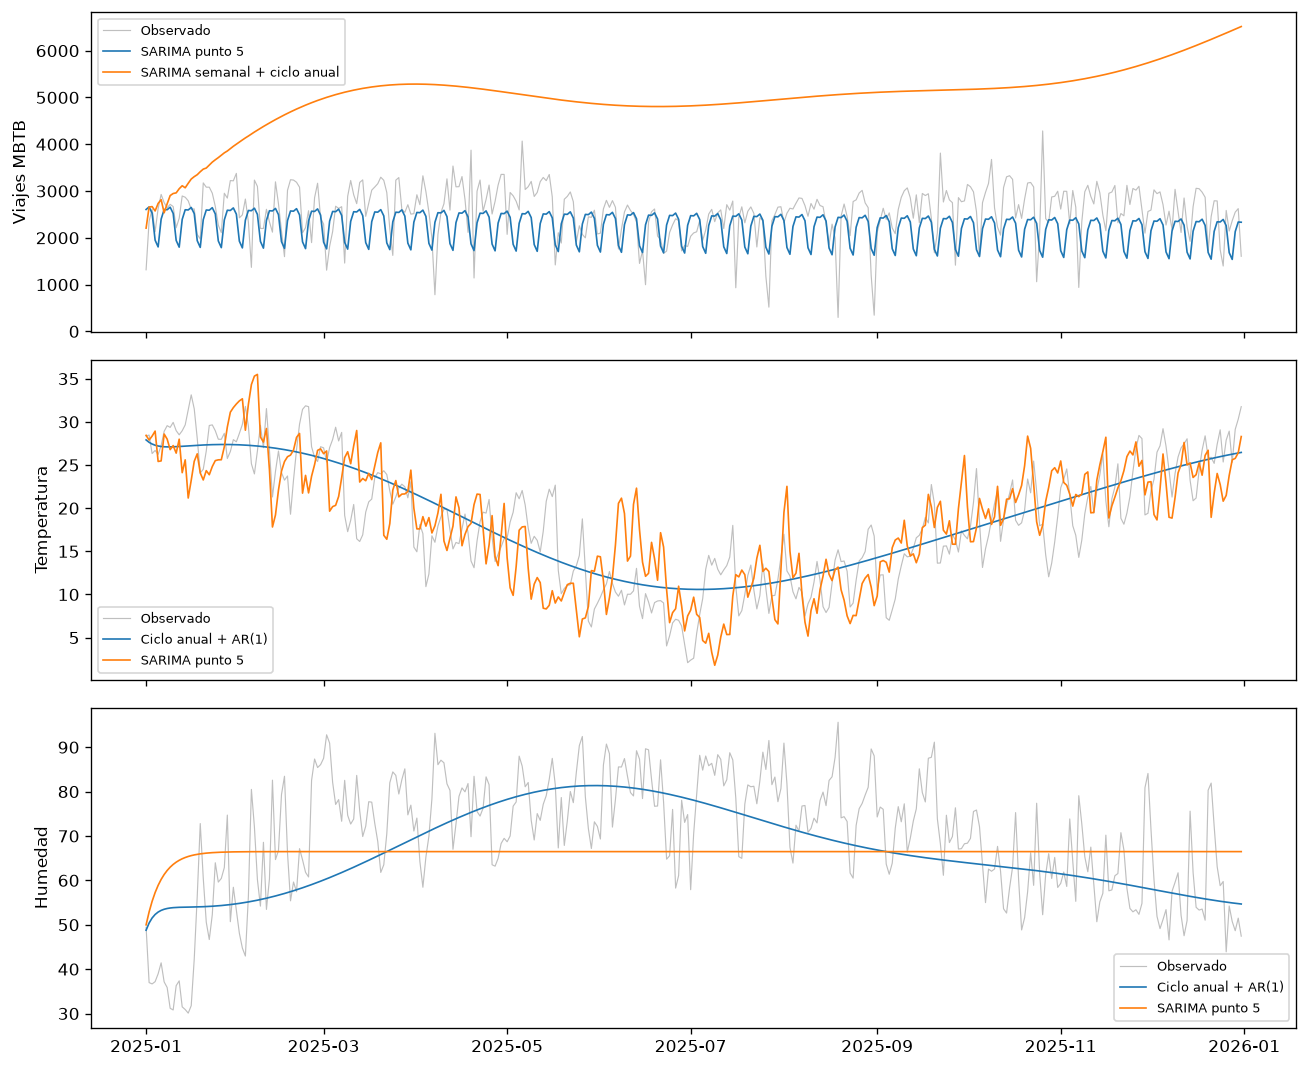

**Humedad:** el cambio de MAE anual respecto de la referencia es **23.8%** (positivo significa mejora; negativo, empeoramiento). La elección se tomó con validación, antes de esta comparación.

**Precipitación:** el cambio de MAE anual respecto de la referencia es **0.0%** (positivo significa mejora; negativo, empeoramiento). La elección se tomó con validación, antes de esta comparación.

**Temperatura:** el cambio de MAE anual respecto de la referencia es **33.0%** (positivo significa mejora; negativo, empeoramiento). La elección se tomó con validación, antes de esta comparación.

**Viajes MBTB:** el cambio de MAE anual respecto de la referencia es **0.0%** (positivo significa mejora; negativo, empeoramiento). La elección se tomó con validación, antes de esta comparación.

In [2]:
OUT=ROOT/'puntos/punto12';OUT.mkdir(exist_ok=True)
filas=[];elecciones={};pronosticos=[]
for nombre,s in series.items():
    train,test=s.loc[:'2024-12-31'],s.loc['2025-01-01':]
    base,val=train.iloc[:-90],train.iloc[-90:]
    opciones=['SARIMA punto 5']
    if nombre!='Precipitación': opciones.append('SARIMA semanal + ciclo anual' if nombre=='Viajes MBTB' else 'Ciclo anual + AR(1)')
    locales=[]
    for tipo in opciones:
        if tipo=='SARIMA punto 5':
            rv,_=ajustar(base,seleccion[nombre]);pv=pronosticar(rv,base,seleccion[nombre],val.index)
            rt,avisos=ajustar(train,seleccion[nombre]);pt=pronosticar(rt,train,seleccion[nombre],test.index)
        else:
            rv,_=fit_estacional(base,nombre,tipo);pv=forecast_estacional(rv,val.index,nombre)
            rt,avisos=fit_estacional(train,nombre,tipo);pt=forecast_estacional(rt,test.index,nombre)
        locales.append({'serie':nombre,'modelo':tipo,'MAE_validacion':metricas(val,pv)['MAE'],
                        'MAE_testing':metricas(test,pt)['MAE'],'RMSE_testing':metricas(test,pt)['RMSE'],'advertencias':avisos})
        pronosticos.append(pd.DataFrame({'fecha':test.index,'serie':nombre,'modelo':tipo,'prediccion':pt.values,'observado':test.values}))
    ganador=min(locales,key=lambda x:x['MAE_validacion'])['modelo'];elecciones[nombre]=ganador
    for row in locales:row['elegido_validacion']=row['modelo']==ganador
    filas+=locales
    display(Markdown(f'**{nombre}:** se elige **{ganador}** por validación.'))
tabla=pd.DataFrame(filas);tabla.to_csv(OUT/'comparacion_estacionalidad.csv',index=False)
(OUT/'seleccion_estacional.json').write_text(json.dumps(elecciones,ensure_ascii=False,indent=2))
pred=pd.concat(pronosticos,ignore_index=True);pred.to_csv(OUT/'predicciones_estacionales.csv',index=False)
display(tabla.round(3))
fig,axes=plt.subplots(3,1,figsize=(11,9),sharex=True)
for ax,nombre in zip(axes,['Viajes MBTB','Temperatura','Humedad']):
    sub=pred[pred.serie==nombre]
    real=sub[sub.modelo=='SARIMA punto 5'];ax.plot(real.fecha,real.observado,color='gray',alpha=.5,lw=.7,label='Observado')
    for tipo,g in sub.groupby('modelo'):ax.plot(g.fecha,g.prediccion,lw=1,label=tipo)
    ax.set_ylabel(nombre);ax.legend(fontsize=8)
fig.tight_layout();fig.savefig(OUT/'estacionalidad.png');plt.show();plt.close(fig)
for nombre,g in tabla.groupby('serie'):
    elegido=g[g.elegido_validacion].iloc[0];base=g[g.modelo=='SARIMA punto 5'].iloc[0]
    cambio=100*(base.MAE_testing-elegido.MAE_testing)/base.MAE_testing
    display(Markdown(f'**{nombre}:** el cambio de MAE anual respecto de la referencia es **{cambio:.1f}%** '
                     '(positivo significa mejora; negativo, empeoramiento). La elección se tomó con validación, antes de esta comparación.'))


## Conclusión

Una diferencia estacional y un patrón de calendario cumplen funciones distintas: la primera resta ciclos anteriores; el segundo representa una forma que se repite. Los resultados muestran cuál funcionó mejor dentro de las alternativas y fechas estudiadas.

Los pronósticos del punto 9 conservan los modelos originalmente seleccionados para mantener la continuidad del trabajo. Las nuevas alternativas se presentan aquí como revisión y necesitarían su propio diagnóstico completo antes de reemplazarlos. El trabajo no identifica relaciones causales ni prueba que los ciclos se mantengan sin cambios.

**Herramientas y referencias:** Pandas y NumPy para los datos; Matplotlib para gráficos; statsmodels para los modelos y pruebas. Statsmodels developers. (s. f.). [Documentación de series temporales](https://www.statsmodels.org/stable/tsa.html).